First Pipeline to run binding energy


In [1]:
!uv pip install fairchem-core

Using Python 3.13.11 environment at: C:\Users\miaom\miniconda3\envs\cms
Audited 1 package in 4.98s


In [2]:
# check through Hugging Face Hub if the package is installed correctly, paste result in chatgpt or claude to confirm
# you mainly need to check off " Read access to contents of all public gated repos you can access" and " Read access to contents of all private gated repos you can access" in tokens settings in Hugging Face Hub, and that the token is correctly set up in your environment variables
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '69d423a991dfba6b651bddfe', 'name': 'umami393', 'fullname': 'Margaret', 'isPro': False, 'avatarUrl': '/avatars/eb54fe80196fee8cdf7c5c7ace19b460.svg', 'orgs': [{'type': 'org', 'id': '64374111a701a7e744c02b0e', 'name': 'princetonu', 'fullname': 'Princeton University', 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/68e396f2b5bb631e9b2fac9a/b3xXusq8Zz3ej8Z6fRTSZ.png'}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'Rep Perm', 'role': 'fineGrained', 'createdAt': '2026-04-06T21:24:55.150Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '67098f31ee3ea12411d3f44e', 'type': 'model', 'name': 'facebook/OMAT24'}, 'permissions': []}, {'entity': {'_id': '67f5bb06b8e3712b3da49bfc', 'type': 'model', 'name': 'facebook/UMA'}, 'permissions': []}, {'entity': {'_id': '69d423a991dfba6b651bddfe', 'type': 'user', 'name': 'umami393'}, 'permissions': ['repo.content.read']}]}}}}


In [28]:
from fairchem.core import pretrained_mlip

predictor = pretrained_mlip.get_predict_unit(
    model_name="uma-s-1p1",
    device="cpu"
)

In [29]:
# test with calculator 
from ase.build import bulk
from fairchem.core import pretrained_mlip, FAIRChemCalculator

device = "cpu"

atoms = bulk("Si")

model_name = "uma-s-1p1"
predictor = pretrained_mlip.get_predict_unit(model_name)
calc = FAIRChemCalculator(predictor, task_name="omat")

atoms.calc = calc
e = atoms.get_potential_energy()
print(e)



-10.82311692799609


In [30]:
from ase.io import read
from ase.build import molecule
from ase.optimize import BFGS

# -------------------------
# Load structures
# -------------------------
mof_74 = read("mg_mof74.cif")
co2 = molecule("CO2")

# -------------------------
# Assign calculator
# -------------------------
mof_74.calc = calc
co2.calc = calc

# -------------------------
# Relax MOF
# -------------------------
opt_mof = BFGS(mof_74, logfile="opt_mof_74.log")
opt_mof.run(fmax=0.01)

E_mof = mof_74.get_potential_energy()
print(f"E(Mg-MOF-74) = {E_mof:.6f} eV")

# Relax CO2
co2.center(vacuum=10.0)  # IMPORTANT (no periodic interactions)

opt_co2 = BFGS(co2, logfile="opt_co2.log")
opt_co2.run(fmax=0.01)

E_co2 = co2.get_potential_energy()
print(f"E(CO2, free) = {E_co2:.6f} eV")

E(Mg-MOF-74) = -1177.415341 eV
E(CO2, free) = -22.596883 eV


In [40]:
import numpy as np
# get indices of metal atoms (Mg)
metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == "Mg"]
metal_positions = mof_74.positions[metal_indices]

In [41]:
# center of unit cell (cartesian)
cell_center = np.dot([0.5, 0.5, 0.5], mof_74.get_cell())

def get_direction(metal_pos):
    direction = cell_center - metal_pos
    return direction / np.linalg.norm(direction)

In [42]:
from ase.geometry import get_distances
import numpy as np

def is_valid_position_full(mof, co2, cutoff=1.6):
    dmat = get_distances(
        mof.positions,
        co2.positions,
        cell=mof.get_cell(),
        pbc=mof.get_pbc()
    )[1]
    return np.min(dmat) > cutoff

In [55]:
def get_directions():
    dirs = [
        [1,0,0], [-1,0,0],
        [0,1,0], [0,-1,0],
        [0,0,1], [0,0,-1]
    ]
    return [np.array(d)/np.linalg.norm(d) for d in dirs]

In [54]:
def place_co2_oriented(mof, co2, metal_index):
    metal_pos = mof.positions[metal_index]

    directions = get_directions()

    for direction in directions:

        for d_mg_o in np.linspace(2.2, 2.8, 7):

            co2_copy = co2.copy()

            # align CO2 axis
            co2_axis = co2_copy.positions[2] - co2_copy.positions[0]
            co2_axis /= np.linalg.norm(co2_axis)

            v = np.cross(co2_axis, direction)
            angle = np.degrees(np.arccos(np.clip(np.dot(co2_axis, direction), -1, 1)))

            if np.linalg.norm(v) > 1e-8:
                co2_copy.rotate(angle, v, center='COM')

            # place oxygen
            target = metal_pos + d_mg_o * direction
            shift = target - co2_copy.positions[0]
            co2_copy.positions += shift

            if is_valid_position_full(mof, co2_copy):

                metadata = {
                    "metal_index": metal_index,
                    "direction": direction,
                    "mg_o_distance": d_mg_o
                }

                return co2_copy, metadata

    return None, None

In [44]:
# combine system + computing binding energy 
def compute_binding_energy(mof, co2_placed):
    system = mof.copy()
    system += co2_placed

    system.calc = calc

    opt = BFGS(system, logfile=None)
    opt.run(fmax=0.05)

    E_total = system.get_potential_energy()

    return E_total - E_mof - E_co2

In [ ]:
# testing only for one magnesium site first (we can loop over all sites later)
mg_idx = 14
print(f"Testing Mg site index: {mg_idx}, symbol = {mof_74[mg_idx].symbol}")

if mof_74[mg_idx].symbol != "Mg":
    raise ValueError(f"Atom index {mg_idx} is not Mg. It is {mof_74[mg_idx].symbol}.")

co2_placed = place_co2_oriented(mof_74, co2, mg_idx)

if co2_placed is None:
    raise RuntimeError("Could not place CO2 near Mg without overlap.")

print("CO2 placed successfully")
print("CO2 positions:\n", co2_placed.positions)

Testing Mg site index: 14, symbol = Mg
CO2 placed successfully
CO2 positions:
 [[8.82231721 3.23474244 1.55310651]
 [9.1357771  2.12758286 1.2903883 ]
 [8.50885984 4.34189321 1.81582265]]


In [ ]:
from ase.io import read, write

# intialize combined system for inspection before relaxation
system = mof_74.copy()
system += co2_placed
system.calc = calc

# inspect Mg-O distances before relaxation
print("Initial Mg–O distances:")
for j in range(len(mof_74), len(system)):
    if system[j].symbol == "O":
        d = system.get_distance(mg_idx, j, mic=True)
        print(d)


# -------------------------
# Relax combined system
# -------------------------
opt_system = BFGS(system, logfile="opt_single_site.log")
opt_system.run(fmax=0.05)

E_total = system.get_potential_energy()
E_bind = E_total - E_mof - E_co2

print(f"E(total)   = {E_total:.6f} eV")
print(f"E(bind)    = {E_bind:.6f} eV")

# -------------------------
# Inspect Mg-O distances after relaxation
# -------------------------
co2_start = len(mof_74)
for j in range(co2_start, len(system)):
    if system[j].symbol == "O":
        d = system.get_distance(mg_idx, j, mic=True)
        print(f"Mg-O distance to O atom {j}: {d:.3f} Å")



Initial Mg–O distances:
1.6197117768940394
3.980278834062521
E(total)   = -1200.531405 eV
E(bind)    = -0.519181 eV
Mg-O distance to O atom 163: 2.364 Å
Mg-O distance to O atom 164: 4.504 Å


In [51]:
from ase.visualize import view

view(system)

<Popen: returncode: None args: ['c:\\Users\\miaom\\miniconda3\\envs\\cms\\py...>

In [52]:
# time to iterate across 3-4 sites 
metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == "Mg"]

# pick first 4 for now
test_sites = metal_indices[:4]

print("Testing sites:", test_sites)

Testing sites: [0, 1, 2, 3]


In [57]:
from ase.visualize import view

for idx in test_sites:
    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)

    if co2_placed is None:
        print(f"Site {idx}: placement failed")
        continue

    system = mof_74.copy()
    system += co2_placed

    print(f"Viewing site {idx}")
    print("Direction:", meta["direction"])
    print("Mg-O distance:", meta["mg_o_distance"])

    view(system)
    input("Press Enter to continue...")

Viewing site 0
Direction: [-1.  0.  0.]
Mg-O distance: 2.8
Viewing site 1
Direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Viewing site 2
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 3
Direction: [1. 0. 0.]
Mg-O distance: 2.8


In [ ]:
results = []

for idx in test_sites:

    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)

    if co2_placed is None:
        print(f"Site {idx}: placement failed")
        continue

    print(f"Site {idx} direction:", meta["direction"])
    print(f"Mg-O distance:", meta["mg_o_distance"])

    system = mof_74.copy()
    system += co2_placed
    system.calc = calc

    opt = BFGS(system, logfile=None)
    opt.run(fmax=0.05)

    E_total = system.get_potential_energy()
    E_bind = E_total - E_mof - E_co2

    results.append({
        "site": idx,
        "E_bind": E_bind,
        "direction": meta["direction"],
        "distance": meta["mg_o_distance"]
    })

Site 0 direction: [-1.  0.  0.]
Mg-O distance: 2.8
Site 1 direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Site 2 direction: [0. 1. 0.]
Mg-O distance: 2.8
Site 3 direction: [1. 0. 0.]
Mg-O distance: 2.8


In [69]:
print("site   start_dist   final_dist   E_bind")
for r in results:
    print(r["site"], r["start_dist"], r["final_mg_o_dist"], r["E_bind"])

site   start_dist   final_dist   E_bind


KeyError: 'start_dist'

In [65]:
# view results arra
for r in results:
    print(f"Site {r['site']}: E_bind = {r['E_bind']:.3f} eV, direction = {r['direction']}, distance = {r['distance']:.2f} Å")   

sites = [r["site"] for r in results]
E_bind = np.array([r["E_bind"] for r in results])
dist = np.array([r["distance"] for r in results])



Site 0: E_bind = -0.552 eV, direction = [-1.0, 0.0, 0.0], distance = 2.80 Å
Site 1: E_bind = -0.566 eV, direction = [0.0, -1.0, 0.0], distance = 2.80 Å
Site 2: E_bind = -0.523 eV, direction = [0.0, 1.0, 0.0], distance = 2.80 Å
Site 3: E_bind = -0.562 eV, direction = [1.0, 0.0, 0.0], distance = 2.80 Å


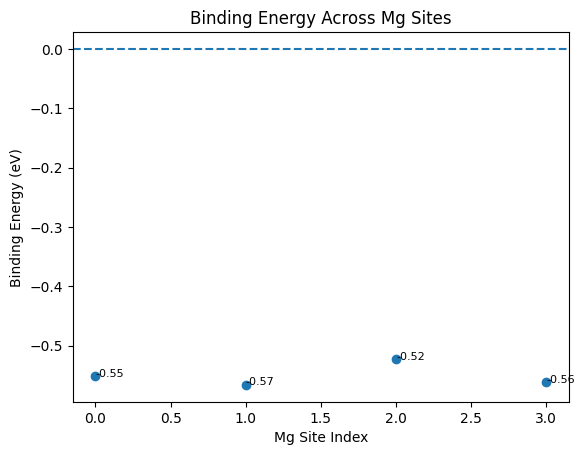

In [66]:
import matplotlib.pyplot as plt

# binding energy plot vs. site index
plt.figure()
plt.scatter(sites, E_bind)

for i, e in zip(sites, E_bind):
    plt.text(i, e, f"{e:.2f}", fontsize=8)

plt.xlabel("Mg Site Index")
plt.ylabel("Binding Energy (eV)")
plt.title("Binding Energy Across Mg Sites")
plt.axhline(0, linestyle="--")

plt.show()

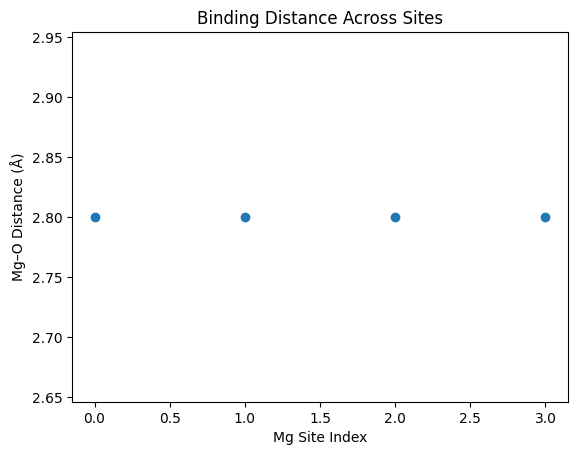

In [67]:
# mg-o distance v. site 
plt.figure()
plt.scatter(sites, dist)

plt.xlabel("Mg Site Index")
plt.ylabel("Mg–O Distance (Å)")
plt.title("Binding Distance Across Sites")

plt.show()

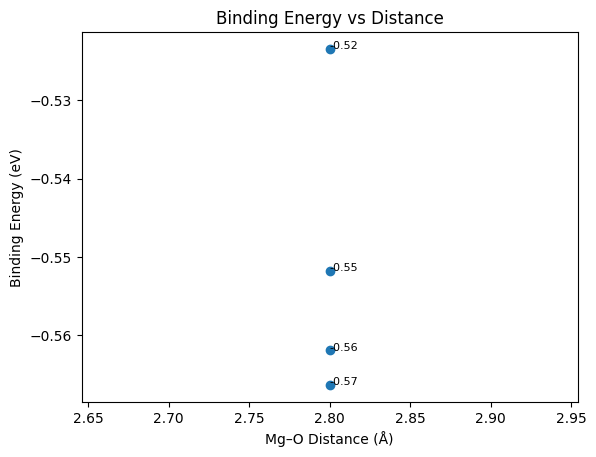

In [68]:
# binding energy vs. distance 
plt.figure()
plt.scatter(dist, E_bind)

for d, e in zip(dist, E_bind):
    plt.text(d, e, f"{e:.2f}", fontsize=8)

plt.xlabel("Mg–O Distance (Å)")
plt.ylabel("Binding Energy (eV)")
plt.title("Binding Energy vs Distance")

plt.show()

In [ ]:
# histogram of binding energies across sites
plt.figure()
plt.hist(E_bind, bins=5)

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Count")
plt.title("Binding Energy Distribution")

plt.show()

In [59]:
# save file of placement + binding energy results for all 4 sites
import json

# convert numpy arrays to lists
for r in results:
    r["direction"] = r["direction"].tolist()

with open("placement_data.json", "w") as f:
    json.dump(results, f, indent=2)